Effettuare  uno  split  90%-10%  tra  training  set  e  validation  set.  Individuare 
eventuali dati mancanti e farne l’imputazione secondo criteri che rispecchino 
la  diversa  stratificazione  sociale  e  distribuzione  di  genere  dei  passeggeri 
ovvero  rimuoverle  se  troppo  sparse.  Effettuare  la  codifica  delle  feature 
categoriche e l’eventuale scaling di tutte le feature, una volta trasformate in 
numeriche. Verificare la presenza di feature multicollneari e ridurle tramite 
opportune  combinazioni  lineari.  Infine,  procedere  alla  feature  selection 
attraverso  una  tecnica embedded  che  impieghi  un  classificatore  come 
modello. La scelta del modello embedded è lasciata al candidato, tenendo 
conto che il problema è di classificazione binaria. 
 
punti ___/ 8 
 
2. Implementare un classificatore SVM non lineare per il data set curato risultato 
del punto 1 con i seguenti iper-parametri: 
 
a. C = {1, 1/sqrt(n_samples)} 
b. kernel={RBF, polinomiale} 
c. grado del kernel polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 6 
 
3. Implementare una piccola rete neurale densa con almeno tre layer nascosti 
in  PyTorch,  utilizzando  la  semplice  API  torchnn.py,  per  eseguire  la 
classificazione binaria. Si dovrà implementare anche il relativo Dataset per 
caricare i dati. I layer nascosti dovranno avere un dropout pari a 0.2. Si utilizzi 
per l’addestramento l’ottimizzatore Adam con weight decay pari a 1x10-4 e 
learning rate dercescente esponenzialmente a partire da 0.01. Implementare 
una  callback  di  early  stopping  con  una  pazienza  sulla  validation  loss  di  5 
epoche e un incremento minimo di miglioramento pari a 0.01; implementare 
anche  una  callback  di  model  checkpoint  per  il  salvataggio  del  solo  miglior 
modello rispetto alla minima validation loss. 
punti ___/ 10 
 
4. Conservare la lista delle accuracy di addestramento e di test su tutte le epoche 
del  classificatore  neurale  e  stamparne  il  grafico.  Confrontare  i  risultati  del 
miglior  classificatore  SVM  e  del  classificatore  neurale  calcolando  e 
stampando, per ciascuno, la matrice di confusione, il valore di accuracy e di 
loss.  Calcolare  e  stampare  in  un  unico  grafico  le  curve  ROC  dei  due 
classificatori binari e stamparne anche le relative AUC.

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = pd.read_csv( '../../dbs/train.csv' )
y = pd.read_csv('../../dbs/test.csv')



X = X.dropna(subset=['Survived'])
y = y.dropna(subset=['Survived'])

perc_col = (X.isna().sum(axis=0) / X.shape[0]) * 100
colonne_da_droppare = perc_col[perc_col > 20].index

X = X.drop(columns=colonne_da_droppare)
y = y.drop(columns=colonne_da_droppare)

X = X.drop(columns=['PassengerId','Ticket','Name'])
y = y.drop(columns=['PassengerId','Ticket','Name'])


X_tmp = X.drop(columns=['Survived'])
y_tmp = X.Survived

X_te = y.drop(columns=['Survived'])
y_te = y.Survived

X_tr, X_val, y_tr, y_val = train_test_split(X_tmp,y_tmp, test_size=0.1, random_state=42, stratify=y_tmp )


In [2]:
print(X_tr.isna().sum())

mode_e = X_tr['Embarked'].mode()[0]
print(mode_e)

Pclass        0
Sex           0
Age         161
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
S


In [2]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median').set_output(transform='pandas')

num_f = X_tr.select_dtypes( include='number').columns.tolist()

print(X_tr.columns.tolist())

startified_medians = X_tr.groupby(['Pclass','Sex'])['Age'].median()

def impute_s(df,medians):
    
    df_copy = df.copy()
    for (pclass,sex),median_val in medians.items():
        condition = (
            df_copy['Age'].isna()
            & (df_copy['Pclass'] == pclass)
            & (df_copy['Sex'] == sex)  
        )
        df_copy.loc[condition, "Age"] = median_val
    return df_copy

X_tr = impute_s(X_tr,startified_medians)
X_val = impute_s(X_val,startified_medians)
X_te = impute_s(X_te,startified_medians)

mode_e = X_tr['Embarked'].mode()[0]

X_tr.loc[ X_tr['Embarked'].isna(), 'Embarked' ] = mode_e
X_val.loc[ X_val['Embarked'].isna(), 'Embarked' ] = mode_e
X_te.loc[ X_te['Embarked'].isna(), 'Embarked' ] = mode_e

X_tr[num_f] = imputer.fit_transform(X_tr[num_f])
X_te[num_f] = imputer.transform(X_te[num_f])
X_val[num_f] = imputer.transform(X_val[num_f])

print(X_tr.isna().sum())
print(X_val.isna().sum())
print(X_te.isna().sum())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [3]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

cat_f = X_tr.select_dtypes( exclude='number').columns.tolist()

encoder = OrdinalEncoder().set_output(transform='pandas')
scaler = StandardScaler().set_output(transform='pandas')

X_tr[cat_f] = encoder.fit_transform( X_tr[cat_f] )
X_val[cat_f] = encoder.transform( X_val[cat_f] )
X_te[cat_f] = encoder.transform( X_te[cat_f] )

X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)


In [4]:
matrix_corr = X_tr.corr().abs()

print(matrix_corr) #dalla matrice di correlazione non vedo feature fortemente correlate tra di loro 
print(X_tr.isna().sum())



            Pclass       Sex       Age     SibSp     Parch      Fare  Embarked
Pclass    1.000000  0.147701  0.413596  0.089452  0.027144  0.563622  0.165170
Sex       0.147701  1.000000  0.094137  0.095339  0.250467  0.211661  0.120222
Age       0.413596  0.094137  1.000000  0.263123  0.176447  0.129580  0.006984
SibSp     0.089452  0.095339  0.263123  1.000000  0.406509  0.161198  0.060343
Parch     0.027144  0.250467  0.176447  0.406509  1.000000  0.204565  0.041373
Fare      0.563622  0.211661  0.129580  0.161198  0.204565  1.000000  0.230873
Embarked  0.165170  0.120222  0.006984  0.060343  0.041373  0.230873  1.000000
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

classifier = RandomForestClassifier(n_estimators=10)
selector = SelectFromModel( estimator= classifier, threshold='median').set_output(transform='pandas')

X_tr = selector.fit_transform( X_tr, y_tr)
X_val = selector.transform(X_val)
X_te = selector.transform(X_te)

print(X_tr)
print(X_val.shape)
print(X_te.shape)

       Pclass       Sex       Age      Fare
86   0.823898  0.735109 -0.980550  0.051433
329 -1.575892 -1.360343 -0.980550  0.546842
517  0.823898  0.735109 -0.308495 -0.163171
844  0.823898  0.735109 -0.905878 -0.488225
408  0.823898  0.735109 -0.607187 -0.506852
..        ...       ...       ...       ...
141  0.823898 -1.360343 -0.532514 -0.507377
736  0.823898 -1.360343  1.408978  0.051433
462 -1.575892  0.735109  1.334305  0.138009
526 -0.375997 -1.360343  1.558324 -0.449659
307 -1.575892 -1.360343 -0.905878  1.615576

[801 rows x 4 columns]
(90, 4)
(418, 4)


2. Implementare un classificatore SVM non lineare per il data set curato risultato 
del punto 1 con i seguenti iper-parametri: 
 
a. C = {1, 1/sqrt(n_samples)} 
b. kernel={RBF, polinomiale} 
c. grado del kernel polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 6 

In [12]:
print(X_te.shape[0])
print(y_te.shape[0])

418
418


In [73]:
from numpy import sqrt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = [
    {
        'C': [1, 1/sqrt(X_tr.shape[0])],
        'kernel' : ['rbf']
    },
    {
         'C': [1, 1/sqrt(X_tr.shape[0])],
        'kernel' : ['poly'],
        'degree' : [3,4]
        
    }
]

search = GridSearchCV(
    estimator = SVC(random_state=29),
    param_grid = param_grid,
    scoring = 'accuracy'
)

search.fit( X_tr , y_tr )

best_model_ml = search.best_estimator_
best_par_ml = search.best_params_

print( f'train acc: {search.best_score_}' )
y_pred_ml = best_model_ml.predict(X_te)
y_scores_ml = best_model_ml.decision_function(X_te)

acc = accuracy_score(y_te, y_pred_ml)

print(f'test acc: {acc}')

train acc: 0.8202251552795031
test acc: 0.7799043062200957


3. Implementare una piccola rete neurale densa con almeno tre layer nascosti 
in  PyTorch,  utilizzando  la  semplice  API  torchnn.py,  per  eseguire  la 
classificazione binaria. Si dovrà implementare anche il relativo Dataset per 
caricare i dati. I layer nascosti dovranno avere un dropout pari a 0.2. Si utilizzi 
per l’addestramento l’ottimizzatore Adam con weight decay pari a 1x10-4 e 
learning rate dercescente esponenzialmente a partire da 0.01. Implementare 
una  callback  di  early  stopping  con  una  pazienza  sulla  validation  loss  di  5 
epoche e un incremento minimo di miglioramento pari a 0.01; implementare 
anche  una  callback  di  model  checkpoint  per  il  salvataggio  del  solo  miglior 
modello rispetto alla minima validation loss. 
punti ___/ 10 
 
4. Conservare la lista delle accuracy di addestramento e di test su tutte le epoche 
del  classificatore  neurale  e  stamparne  il  grafico.  Confrontare  i  risultati  del 
miglior  classificatore  SVM  e  del  classificatore  neurale  calcolando  e 
stampando, per ciascuno, la matrice di confusione, il valore di accuracy e di 
loss.  Calcolare  e  stampare  in  un  unico  grafico  le  curve  ROC  dei  due 
classificatori binari e stamparne anche le relative AUC.

In [33]:


from torch import nn
import torch
import torchnn as utils  
from torch.utils.data import TensorDataset 
import numpy as np

train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
     TensorDataset(torch.tensor(np.array(X_tr), dtype=torch.float32), torch.tensor(np.array(y_tr), dtype=torch.long)),
     TensorDataset(torch.tensor(np.array(X_val), dtype=torch.float32), torch.tensor(np.array(y_val), dtype=torch.long)),
     TensorDataset(torch.tensor(np.array(X_te), dtype=torch.float32), torch.tensor(np.array(y_te), dtype=torch.long))
)

class Net(nn.Module):
    
    def __init__(self, depth, hidden_size):
        super().__init__()
        
        self.activation = nn.ReLU()
        layers = [ nn.Linear(X_tr.shape[1], hidden_size), self.activation ]
        
        for _ in range(depth - 2):
            layers += [ nn.Dropout(0.2), nn.Linear(hidden_size,hidden_size), self.activation ]
            
        layers += [nn.Linear(hidden_size,2), nn.LogSoftmax(dim=1) ]
        
        self.layers = nn.Sequential(*layers)
        
    def forward(self,X):
        return self.layers(X)
    
    

Shape e tipo dei campioni: torch.Size([64, 4]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [79]:
from sklearn.metrics import roc_auc_score
import copy

def eval_loop(model, dataloader, device, loss_fn):
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_pred_prob = []

    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())
            y_pred_prob.extend( torch.exp(pred).cpu().numpy() )

    test_loss /= num_batches
    accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set

    auc = roc_auc_score(y_true, np.array(y_pred_prob)[:,1])
    

    return test_loss, accuracy, auc, (y_true,y_pred,np.array(y_pred_prob)[:,1])

class SaveBestModel:
    def __init__(self):
        self.model = None
        self.op = None
        self.acc = -1
        self.loss = float('inf')
        
    def __call__(self, model, op, acc, epoch, tr_loss, val_loss,te_loss):
        if val_loss > self.loss:
            return
        
        self.loss = val_loss
        self.model = copy.deepcopy( model.state_dict() )
        self.op = copy.deepcopy( op.state_dict() )
        self.acc = acc
        self.epoch = epoch
        self.tr_loss = tr_loss
        self.val_loss = val_loss
        self.te_loss = te_loss
    
    def save_model(self, path):
   
        torch.save({
            'epoch': self.epoch,
            'model_state_dict': self.model,               # configurazione di tutti i layer *addestrabili* del modello
            'optimizer_state_dict': self.op,     # configurazione e operparametri dell'ottimizzatore
            'training_loss': self.tr_loss,
            'validation_loss': self.val_loss,
            'test_loss': self.te_loss,
            'accuracy': self.acc
    }, path)

In [85]:
from tqdm import trange


model = Net(5,64)             
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

epochs = 30
op = torch.optim.Adam(params=model.parameters(), lr = 0.01, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.LinearLR(  op, start_factor=1.0, end_factor=0.1, total_iters=30)
early_stopping = utils.EarlyStopping(patience=5,min_delta=0.01)
criterion = nn.NLLLoss()

train_loss, validation_loss, test_loss = [], [], []
accuracy_train,accuracy_val, accuracy_test_l = [],[],[]

num_batches = len(train_dataloader.batch_sampler) 
bm = SaveBestModel()
# Ciclo di addestramento con early stopping
for epoch in range(1,epochs+1):

    # Progress bar
    pbar = trange(num_batches)
    pbar.set_description(desc='Epoch {:4d}'.format(epoch))

    epoch_train_loss = utils.train_loop(model, train_dataloader, op, device, pbar, loss_fn=criterion)
    train_loss.append(epoch_train_loss)
    
    _, epoch_accuracy_train, _, _ = eval_loop(model, train_dataloader, device, loss_fn=criterion)
    accuracy_train.append(epoch_accuracy_train)

    epoch_validate_loss, epoch_accuracy_val, auc, pred = eval_loop(model, val_dataloader, device, loss_fn=criterion)
    validation_loss.append(epoch_validate_loss)
    accuracy_val.append(epoch_accuracy_val)
   
    epoch_test_loss, epoch_accuracy_test_l, auc, pred = eval_loop(model, test_dataloader, device, loss_fn=criterion)

    test_loss.append(epoch_test_loss)
    accuracy_test_l.append(epoch_accuracy_test_l)
   
    bm(model,op,acc,epoch,epoch_train_loss,epoch_validate_loss,epoch_test_loss)
    
    val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '

    print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}Test loss: {epoch_test_loss:6.4f} Accuracy: {epoch_accuracy_test_l:6.2f}\nMetrics:")
    

    early_stopping(epoch_validate_loss)
    if early_stopping.early_stop:
        break

    # scheduler dell'iperparametro
    if scheduler is not None:
        scheduler.step()



Epoch    1: 100%|██████████| 13/13 [00:01<00:00,  7.59it/s]


Train loss: 0.5441
Validation loss: 0.5220
Test loss: 0.5088 Accuracy:   0.78
Metrics:


Epoch    2: 100%|██████████| 13/13 [00:01<00:00,  7.72it/s]


Train loss: 0.4781
Validation loss: 0.4863
Test loss: 0.4895 Accuracy:   0.77
Metrics:


Epoch    3: 100%|██████████| 13/13 [00:01<00:00,  7.76it/s]


...

Train loss: 0.4201
Validation loss: 0.5360
Test loss: 0.4905 Accuracy:   0.77
Metrics:


Epoch    7: 100%|██████████| 13/13 [00:01<00:00,  7.75it/s]


Train loss: 0.4226
Validation loss: 0.5690
Test loss: 0.5111 Accuracy:   0.77
Metrics:


Epoch    8: 100%|██████████| 13/13 [00:01<00:00,  7.68it/s]


Train loss: 0.4315
Validation loss: 0.5264
Test loss: 0.4869 Accuracy:   0.77
Metrics:


In [86]:


model.load_state_dict( bm.model )
op.load_state_dict( bm.op )
test_loss, accuracy_test, auc, pred = eval_loop(model, test_dataloader, device, loss_fn=criterion)


test acc ML: 0.7799043062200957
test acc DL: 0.7488038277511961 
test loss DL: 0.5134591289928981 


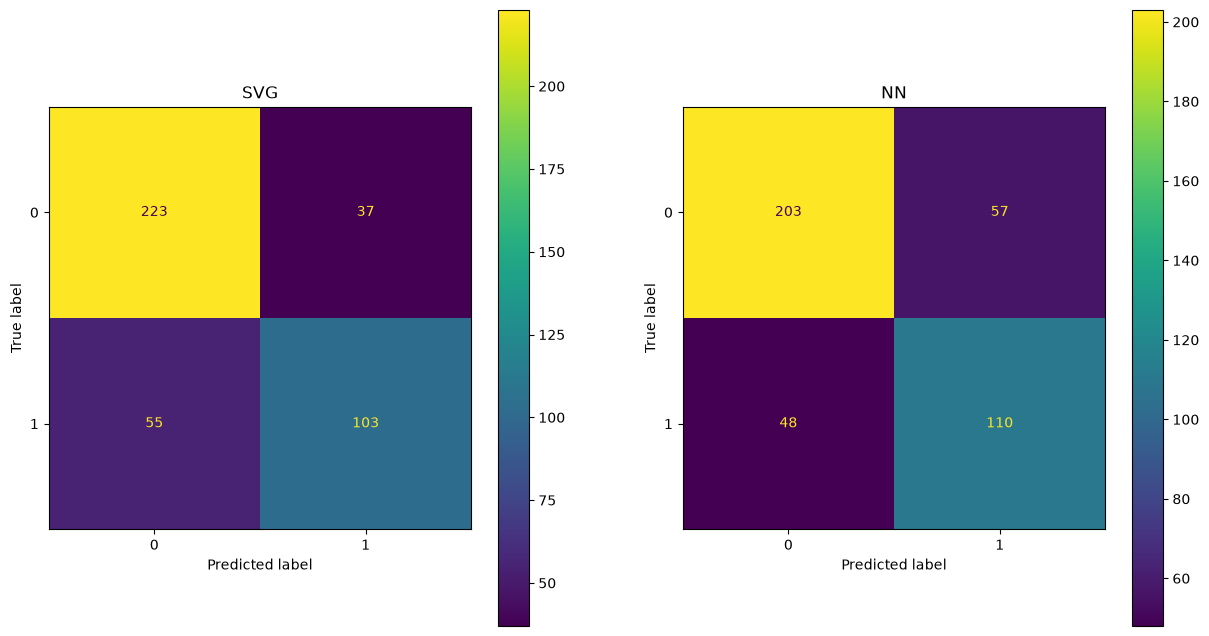

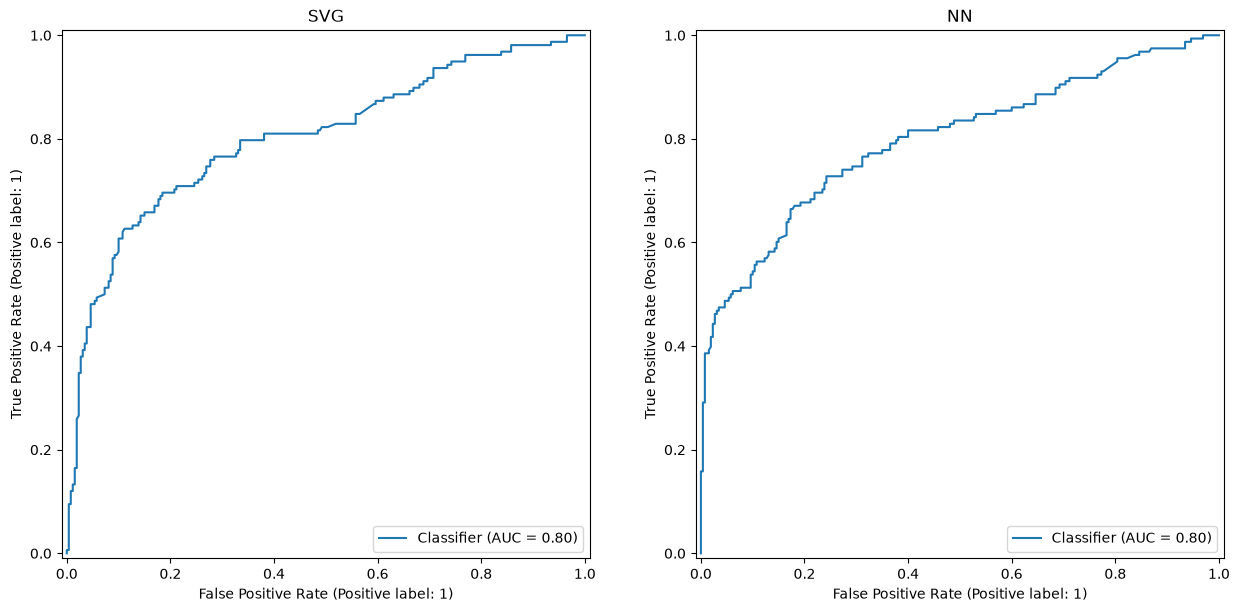

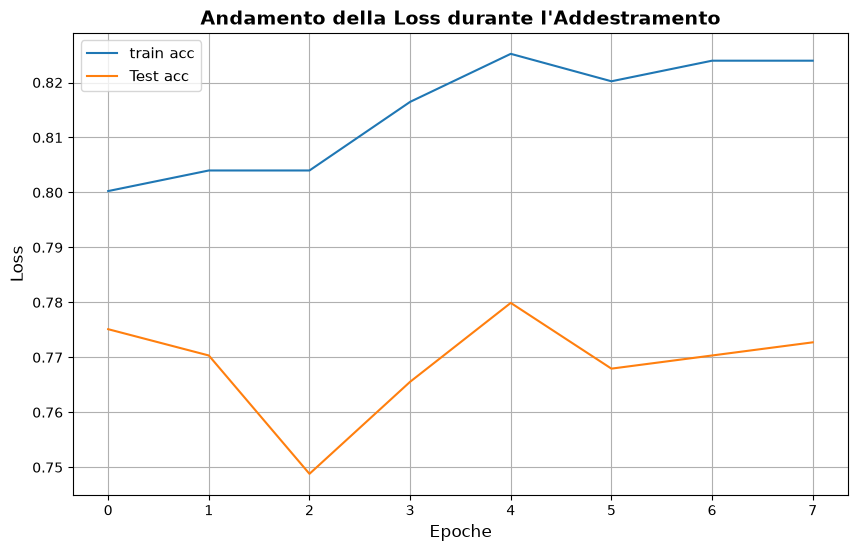

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

print(f'test acc ML: {acc}')
print( f'test acc DL: {accuracy_score(pred[0],pred[1])} ')
print( f'test loss DL: {test_loss} ')

fig, ax = plt.subplots(1, 2, figsize=(15,8))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_ml, ax= ax[0])
ConfusionMatrixDisplay.from_predictions(pred[0], pred[1], ax= ax[1])
ax[0].set_title('SVG')
ax[1].set_title('NN')

fig, ax = plt.subplots(1, 2, figsize=(15,8))
RocCurveDisplay.from_predictions(y_te, y_scores_ml, ax=ax[0])
RocCurveDisplay.from_predictions(pred[0], pred[2], ax=ax[1])
ax[0].set_title('SVG')
ax[1].set_title('NN')


plt.figure(figsize=(10, 6))

plt.plot(accuracy_train, label='train acc')
plt.plot(accuracy_test_l, label='Test acc')
plt.title('Andamento della Loss durante l\'Addestramento', fontsize=14, fontweight='bold')
plt.xlabel('Epoche', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()
